# 07 - Visualizacao da Segmentacao Binarizada

Le as tabelas analiticas persistidas pelo notebook 06, reconstrói a base linha a linha em memoria para a execucao escolhida em `config.toml` e exporta graficos e tabelas em PNG+CSV para consumo posterior por IA.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams['figure.max_open_warning'] = 0
import pandas as pd
from IPython.display import display

root_dir = Path.cwd()
if not (root_dir / 'src').exists() and (root_dir.parent / 'src').exists():
    root_dir = root_dir.parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.analysis import build_binarized_metrics_dataframe
from src.config import SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO
from src.io.path_resolver import PathResolver
from src.repositories import (
    AnaliseSegmentacaoBinarizadaInteracaoTagEstrategiaRepository,
    AnaliseSegmentacaoBinarizadaIntervaloConfiancaRepository,
    AnaliseSegmentacaoBinarizadaResumoEstrategiaRepository,
    AnaliseSegmentacaoBinarizadaResumoModeloEstrategiaRepository,
    AnaliseSegmentacaoBinarizadaTesteEstrategiaRepository,
    ImagemRepository,
)
from src.visualization import (
    build_artifact_output_dir,
    build_artifact_stem,
    export_figure_with_csv,
    export_table_csv,
    plot_metric_bars_by_model,
    plot_metric_correlation_heatmap,
    plot_metric_distribution_by_model,
    plot_metric_scatter,
    plot_model_tag_interaction_heatmap,
    plot_pairwise_pvalue_heatmap,
    plot_simple_regression,
)


/home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento das tabelas analiticas e da base linha a linha

A visualizacao usa a base linha a linha reconstruida a partir do SQLite e as tabelas analiticas persistidas pelo notebook 06 para a execucao configurada da segmentacao binarizada.


In [2]:
def _registros_para_dataframe(registros, columns):
    return pd.DataFrame([{column: getattr(registro, column) for column in columns} for registro in registros], columns=columns)

metric_names = ['iou', 'precision', 'recall']
metric_pairs = [('iou', 'precision'), ('iou', 'recall'), ('precision', 'recall')]
interaction_metrics = ['iou', 'precision', 'recall']
path_resolver = PathResolver.from_config()
artifact_output_dir = build_artifact_output_dir(
    path_resolver.generated_dir,
    'notebook_07_segmentacao_binarizada',
)

imagem_repository = ImagemRepository()
# Docs: docs/decisoes-tecnicas/analise-da-segmentacao-binarizada-por-execucao-fixa.md
df_base = build_binarized_metrics_dataframe(
    imagem_repository.list(),
    execucao_escolhida=SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO,
)
df_base_por_estrategia = df_base.drop(columns=['modelo']).rename(columns={'estrategia_binarizacao': 'modelo'})

df_resumo_estrategia = _registros_para_dataframe(
    AnaliseSegmentacaoBinarizadaResumoEstrategiaRepository().list(),
    ['estrategia_binarizacao', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_resumo_modelo_estrategia = _registros_para_dataframe(
    AnaliseSegmentacaoBinarizadaResumoModeloEstrategiaRepository().list(),
    ['nome_modelo', 'estrategia_binarizacao', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better'],
)
df_intervalo_confianca = _registros_para_dataframe(
    AnaliseSegmentacaoBinarizadaIntervaloConfiancaRepository().list(),
    ['nome_modelo', 'estrategia_binarizacao', 'metric_name', 'statistic_name', 'count', 'estimate', 'ci_low', 'ci_high', 'confidence_level', 'n_resamples', 'higher_is_better'],
)
df_testes_estrategia = _registros_para_dataframe(
    AnaliseSegmentacaoBinarizadaTesteEstrategiaRepository().list(),
    ['metric_name', 'modelo_origem', 'comparison_scope', 'test_name', 'group_a', 'group_b', 'n_group_a', 'n_group_b', 'statistic', 'p_value', 'p_value_adjusted', 'effect_size', 'effect_size_label', 'mean_group_a', 'mean_group_b', 'median_group_a', 'median_group_b', 'favored_group'],
)
df_interacoes_tag_estrategia = _registros_para_dataframe(
    AnaliseSegmentacaoBinarizadaInteracaoTagEstrategiaRepository().list(),
    ['estrategia_binarizacao', 'tag_name', 'metric_name', 'count_com_tag', 'count_sem_tag', 'mean_com_tag', 'mean_sem_tag', 'median_com_tag', 'median_sem_tag', 'delta_mean', 'delta_median', 'relative_delta_mean', 'adjusted_delta_mean', 'adjusted_delta_median', 'impact_direction', 'higher_is_better'],
)

print(f'Execucao escolhida para a analise binarizada: {SEGMENTACAO_BINARIZADA_ANALISE_EXECUCAO}')
print(f'Registros da base linha a linha: {len(df_base)}')
print(f'Resumo por estrategia: {len(df_resumo_estrategia)}')
print(f'Resumo por modelo + estrategia: {len(df_resumo_modelo_estrategia)}')
print(f'Intervalos de confianca: {len(df_intervalo_confianca)}')
print(f'Testes entre estrategias: {len(df_testes_estrategia)}')
print(f'Interacoes estrategia x tag: {len(df_interacoes_tag_estrategia)}')
print(f'Diretorio de artefatos: {artifact_output_dir}')


Execucao escolhida para a analise binarizada: 1
Registros da base linha a linha: 43344
Resumo por estrategia: 24
Resumo por modelo + estrategia: 336
Intervalos de confianca: 672
Testes entre estrategias: 1305
Interacoes estrategia x tag: 144
Diretorio de artefatos: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_07_segmentacao_binarizada


## Comparacao geral entre estrategias

Este bloco resume cada metrica no nivel da estrategia de binarizacao. Ele responde primeiro a pergunta mais direta: qual estrategia tende a performar melhor no agregado, antes de abrir por modelo.


metric_name,estrategia_binarizacao,iou,precision,recall
0,GaussianaOpeningAlta,0.901688,0.948601,0.922651
1,GaussianaOpeningBaixa,0.906866,0.943035,0.934514
2,HistereseClosingAlta,0.906608,0.943729,0.932816
3,HistereseClosingBaixa,0.907508,0.936823,0.942262
4,LimiarFixoAlta,0.898515,0.950161,0.917656
5,LimiarFixoBaixa,0.907185,0.940637,0.937337
6,OtsuOpeningAlta,0.914438,0.949876,0.939945
7,OtsuOpeningBaixa,0.918134,0.943965,0.952133


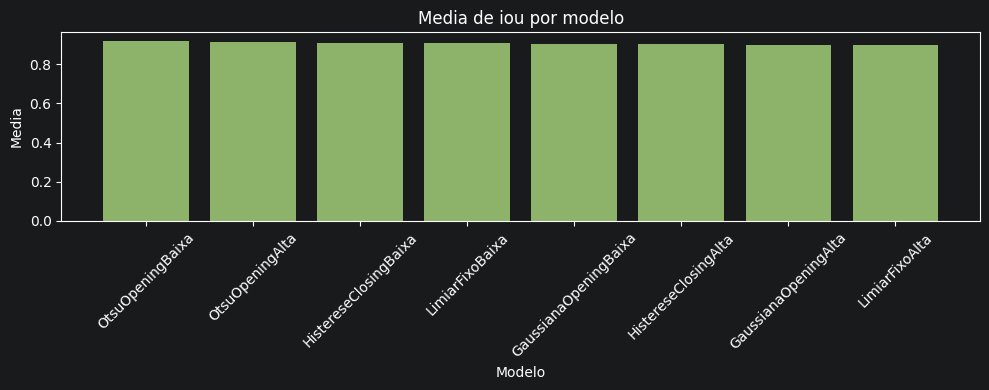

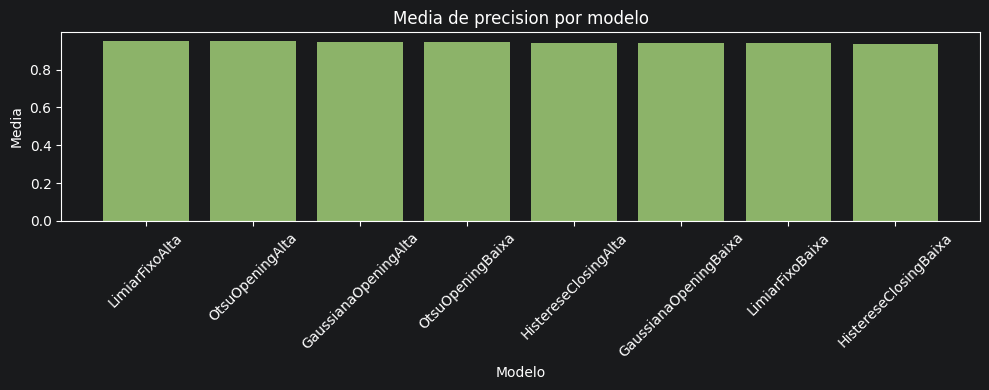

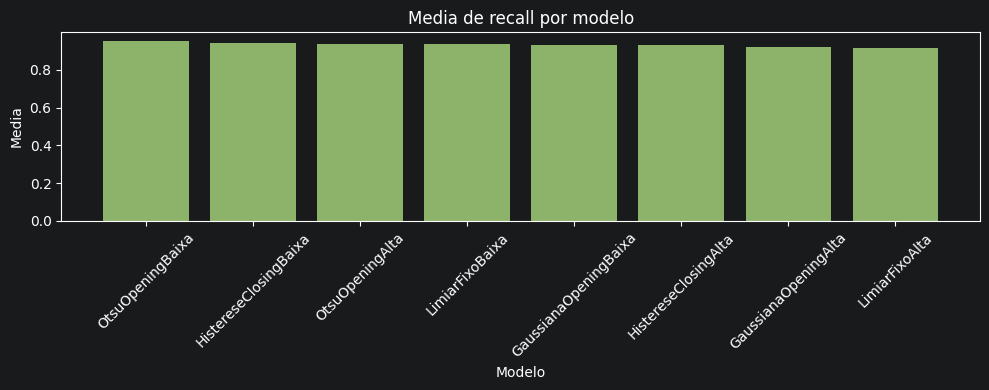

In [3]:
texto_estrategias = 'Este bloco resume cada metrica no nivel da estrategia de binarizacao. Ele responde primeiro a pergunta mais direta: qual estrategia tende a performar melhor no agregado, antes de abrir por modelo.'
df_tabela_estrategias = df_resumo_estrategia.pivot(index='estrategia_binarizacao', columns='metric_name', values='mean').sort_index().reset_index()
display(df_tabela_estrategias)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_07_segmentacao_binarizada', 'tabela', 'resumo_estrategia_media'), df_tabela_estrategias)

df_resumo_estrategia_plot = df_resumo_estrategia.rename(columns={'estrategia_binarizacao': 'nome_modelo'})
for metric_name in metric_names:
    df_plot = df_resumo_estrategia.loc[df_resumo_estrategia['metric_name'] == metric_name, ['estrategia_binarizacao', 'metric_name', 'count', 'mean', 'median', 'std', 'min', 'max', 'q1', 'q3', 'iqr', 'higher_is_better']].copy()
    fig, _ = plot_metric_bars_by_model(df_resumo_estrategia_plot, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'estrategias', 'media', metric_name),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Distribuicoes por estrategia

Os boxplots ajudam a ver dispersao e outliers por estrategia, sem misturar isso com a identidade do modelo.


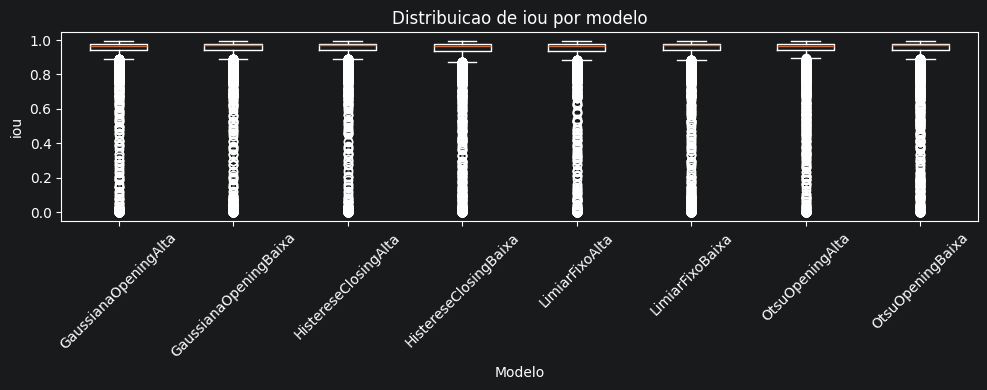

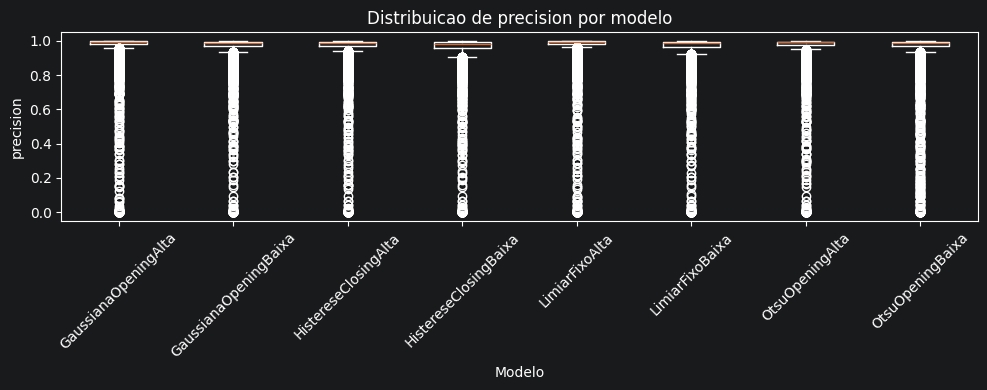

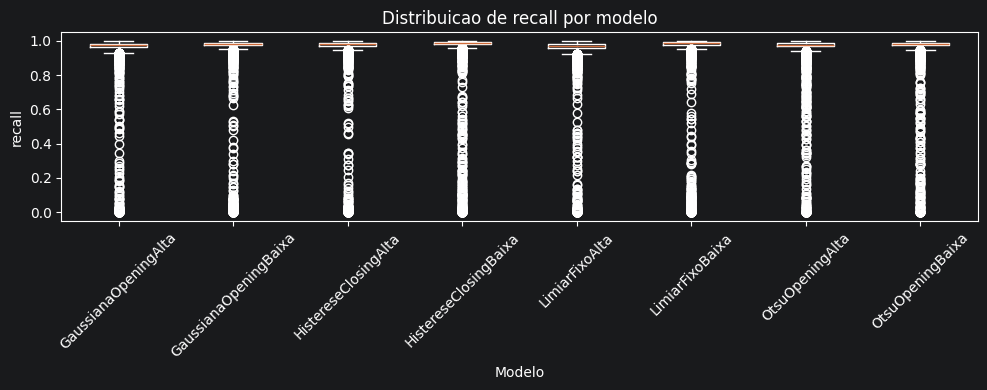

In [4]:
texto_distribuicao = 'Os boxplots ajudam a ver dispersao e outliers por estrategia, sem misturar isso com a identidade do modelo.'

for metric_name in metric_names:
    df_plot = df_base_por_estrategia[['modelo', metric_name, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_metric_distribution_by_model(df_base_por_estrategia, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'distribuicao', metric_name, 'por_estrategia'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Comparacao estatistica entre estrategias

Aqui entram os testes nao parametricos entre estrategias.


,metric_name,modelo_origem,comparison_scope,test_name,group_a,group_b,n_group_a,n_group_b,statistic,p_value,p_value_adjusted,effect_size,effect_size_label,mean_group_a,mean_group_b,median_group_a,median_group_b,favored_group
0,iou,__global__,global,kruskal_wallis,all_models,,43344,8,233.496071,8.970967e-47,8.970967e-47,NaN,NaN,0.907618,0.907618,0.967578,0.967578,NaN
10,iou,__global__,pairwise,dunn_holm,GaussianaOpeningBaixa,LimiarFixoAlta,5418,5418,10.631580,0.000000e+00,0.000000e+00,0.118080,negligible,0.906866,0.898515,0.969013,0.963844,GaussianaOpeningBaixa
15,iou,__global__,pairwise,dunn_holm,HistereseClosingAlta,LimiarFixoAlta,5418,5418,10.434664,0.000000e+00,0.000000e+00,0.116733,negligible,0.906608,0.898515,0.968930,0.963844,HistereseClosingAlta
19,iou,__global__,pairwise,dunn_holm,HistereseClosingBaixa,LimiarFixoAlta,5418,5418,8.636461,0.000000e+00,0.000000e+00,0.092611,negligible,0.907508,0.898515,0.967973,0.963844,HistereseClosingBaixa
23,iou,__global__,pairwise,dunn_holm,LimiarFixoAlta,LimiarFixoBaixa,5418,5418,-10.479834,0.000000e+00,0.000000e+00,-0.115073,negligible,0.898515,0.907185,0.963844,0.968941,LimiarFixoBaixa
25,iou,__global__,pairwise,dunn_holm,LimiarFixoAlta,OtsuOpeningBaixa,5418,5418,-10.348857,0.000000e+00,0.000000e+00,-0.115716,negligible,0.898515,0.918134,0.963844,0.968794,OtsuOpeningBaixa
1,iou,__global__,pairwise,dunn_holm,GaussianaOpeningAlta,GaussianaOpeningBaixa,5418,5418,-8.004560,1.110223e-15,2.553513e-14,-0.089034,negligible,0.901688,0.906866,0.964985,0.969013,GaussianaOpeningBaixa
24,iou,__global__,pairwise,dunn_holm,LimiarFixoAlta,OtsuOpeningAlta,5418,5418,-7.945444,1.998401e-15,4.396483e-14,-0.090117,negligible,0.898515,0.914438,0.963844,0.967684,OtsuOpeningAlta
5,iou,__global__,pairwise,dunn_holm,GaussianaOpeningAlta,LimiarFixoBaixa,5418,5418,-7.852815,3.996803e-15,8.393286e-14,-0.086314,negligible,0.901688,0.907185,0.964985,0.968941,LimiarFixoBaixa
2,iou,__global__,pairwise,dunn_holm,GaussianaOpeningAlta,HistereseClosingAlta,5418,5418,-7.807645,5.773160e-15,1.154632e-13,-0.087515,negligible,0.901688,0.906608,0.964985,0.968930,HistereseClosingAlta


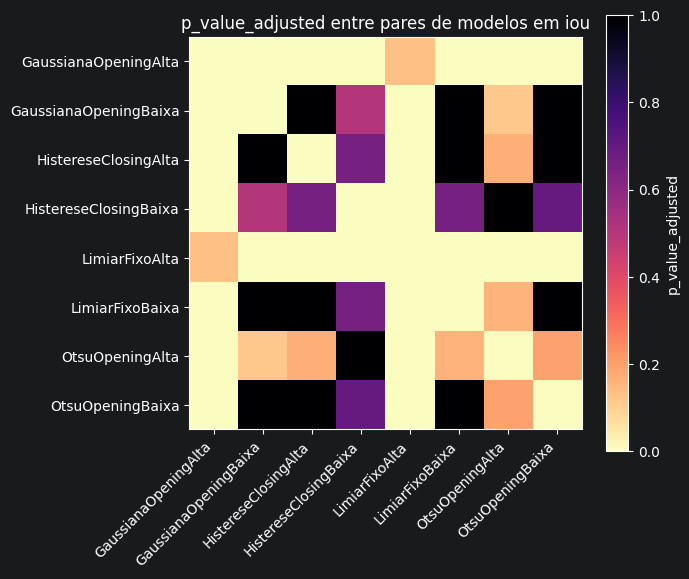

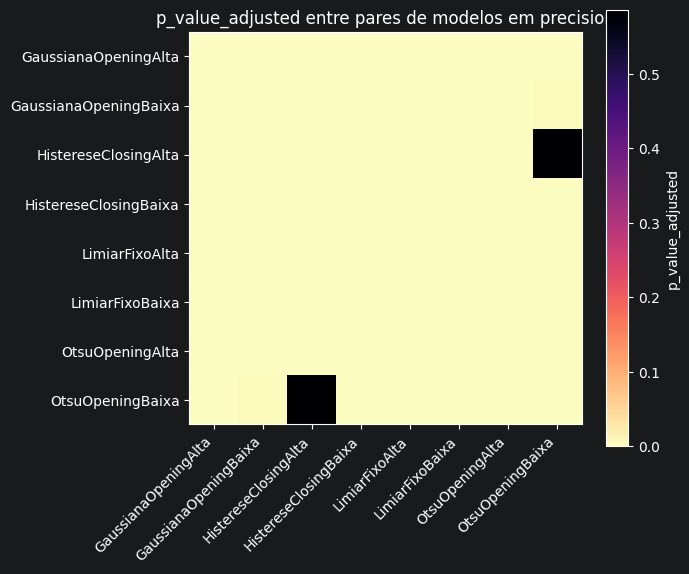

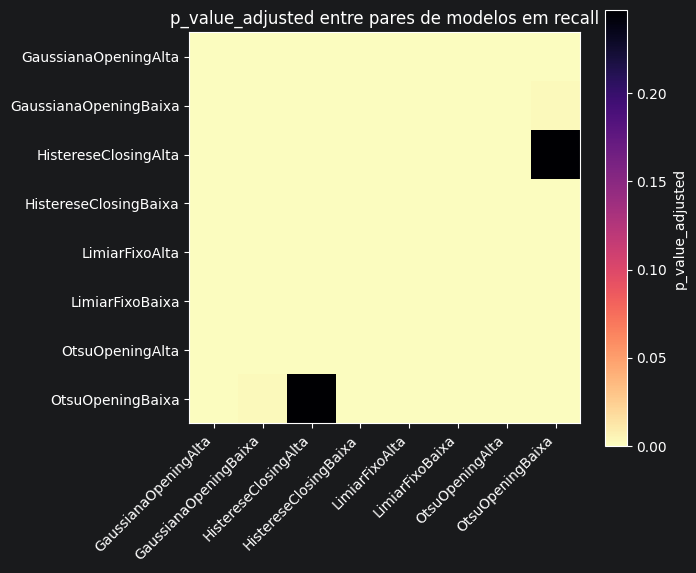

In [5]:
texto_testes = 'Aqui entram os testes nao parametricos entre estrategias.'
df_testes_estrategia_global = df_testes_estrategia.loc[df_testes_estrategia['modelo_origem'] == '__global__'].copy()
if df_testes_estrategia_global.empty:
    print('Nao ha testes globais entre estrategias disponiveis no SQLite atual.')
else:
    df_tabela_testes = df_testes_estrategia_global.sort_values(['metric_name', 'comparison_scope', 'p_value_adjusted']).head(30).copy()
    display(df_tabela_testes)
    export_table_csv(artifact_output_dir, build_artifact_stem('notebook_07_segmentacao_binarizada', 'tabela', 'testes_estrategia_global_top30'), df_tabela_testes)

    for metric_name in metric_names:
        df_plot = df_testes_estrategia_global.loc[(df_testes_estrategia_global['metric_name'] == metric_name) & (df_testes_estrategia_global['comparison_scope'] == 'pairwise')].copy()
        labels = sorted(set(df_plot['group_a']) | set(df_plot['group_b']))
        matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
        for label in labels:
            matrix.loc[label, label] = 0.0
        for row in df_plot.to_dict(orient='records'):
            matrix.loc[str(row['group_a']), str(row['group_b'])] = float(row['p_value_adjusted'])
            matrix.loc[str(row['group_b']), str(row['group_a'])] = float(row['p_value_adjusted'])
        matrix = matrix.reset_index().rename(columns={'index': 'estrategia_binarizacao'})
        fig, _ = plot_pairwise_pvalue_heatmap(df_testes_estrategia_global, metric_name)
        export_figure_with_csv(
            artifact_output_dir,
            build_artifact_stem('notebook_07_segmentacao_binarizada', 'comparacao_estatistica', 'p_value_adjusted', metric_name),
            fig,
            matrix,
        )
        plt.show()
        plt.close(fig)


## Analise bivariada e correlacao

Aqui verificamos associacao entre `iou`, `precision` e `recall`.


,metric_name,iou,precision,recall
0,iou,1.000000,0.834912,0.948169
1,precision,0.834912,1.000000,0.745773
2,recall,0.948169,0.745773,1.000000


,metric_name,iou,precision,recall
0,iou,1.000000,0.659517,0.649156
1,precision,0.659517,1.000000,0.030169
2,recall,0.649156,0.030169,1.000000


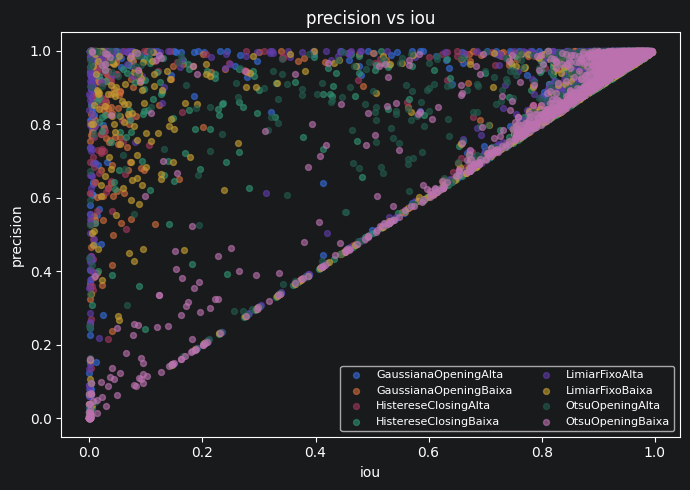

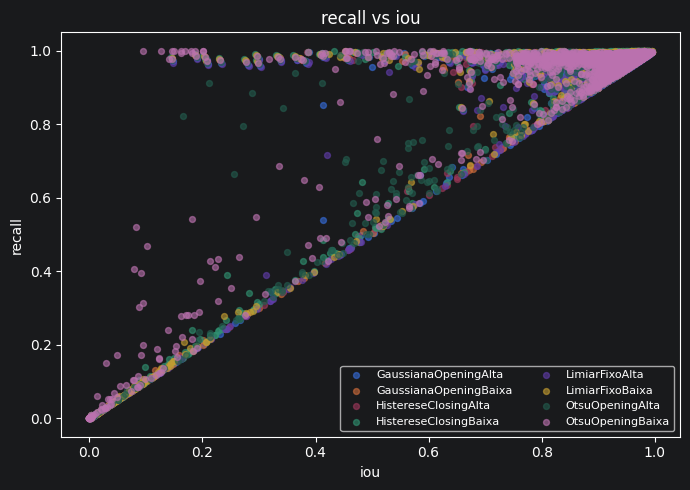

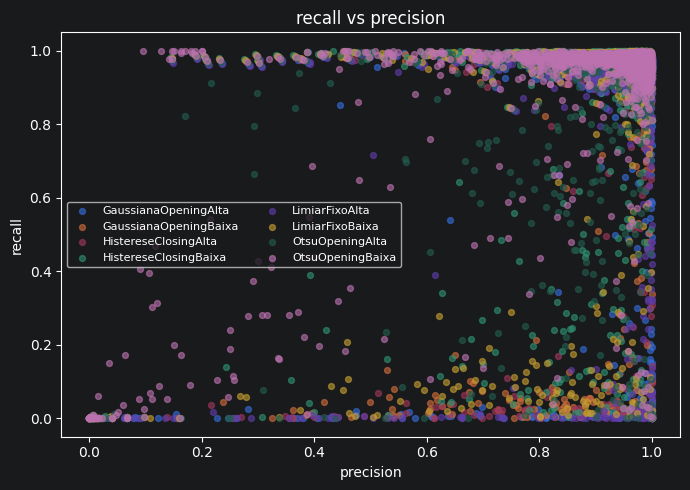

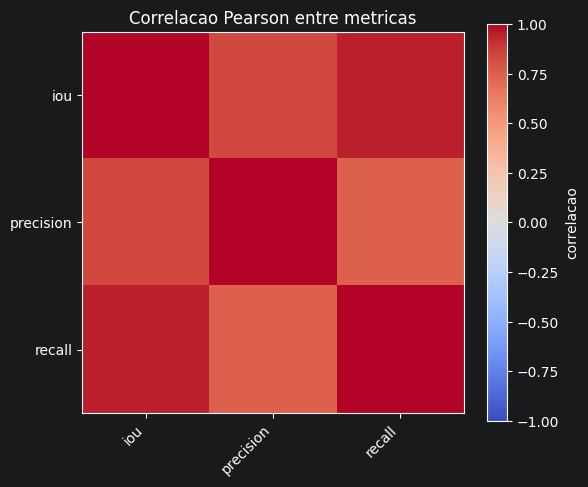

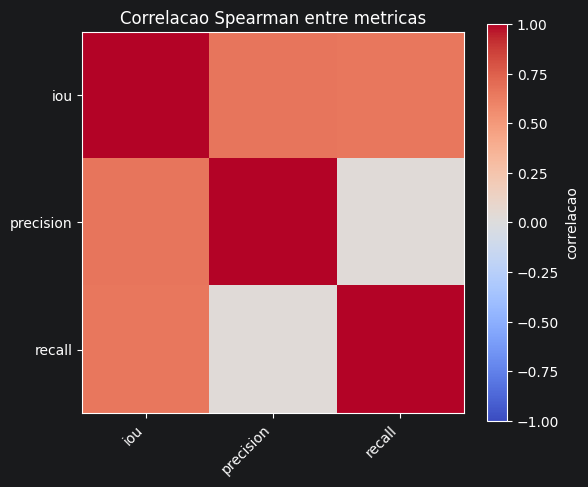

In [6]:
texto_correlacao = 'Aqui verificamos associacao entre iou, precision e recall.'
df_corr_pearson = df_base[metric_names].corr(method='pearson').reset_index().rename(columns={'index': 'metric_name'})
df_corr_spearman = df_base[metric_names].corr(method='spearman').reset_index().rename(columns={'index': 'metric_name'})
display(df_corr_pearson)
display(df_corr_spearman)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_07_segmentacao_binarizada', 'tabela', 'correlacao_pearson'), df_corr_pearson)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_07_segmentacao_binarizada', 'tabela', 'correlacao_spearman'), df_corr_spearman)

for x_metric, y_metric in metric_pairs:
    df_plot = df_base_por_estrategia[['modelo', x_metric, y_metric, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_metric_scatter(df_base_por_estrategia, x_metric, y_metric)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'dispersao', y_metric, 'vs', x_metric, 'por_estrategia'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)

for method in ['pearson', 'spearman']:
    correlation = df_base[metric_names].corr(method=method).reset_index().rename(columns={'index': 'metric_name'})
    fig, _ = plot_metric_correlation_heatmap(df_base, metric_names, method)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'correlacao', method, 'entre_metricas'),
        fig,
        correlation,
    )
    plt.show()
    plt.close(fig)


## Regressao simples

A regressao simples usa `num_tags_problema` como proxy de dificuldade.


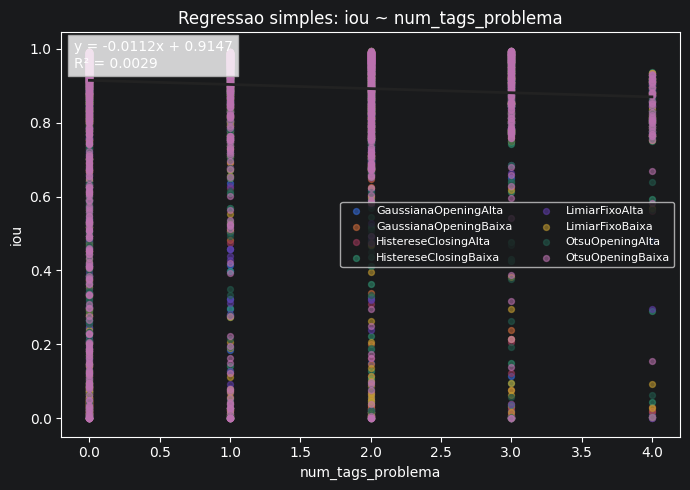

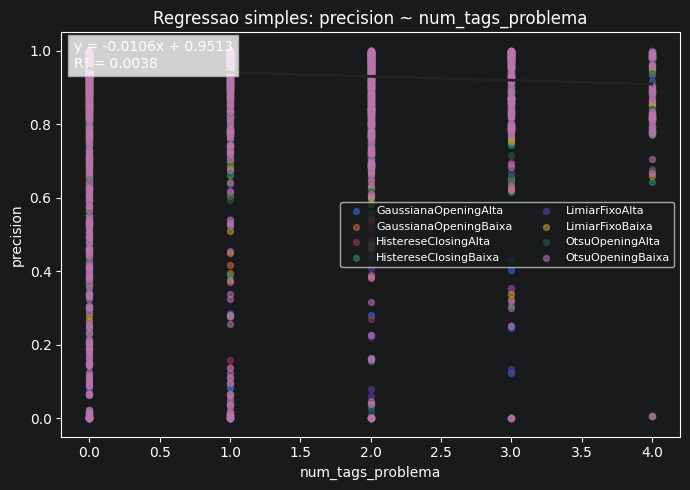

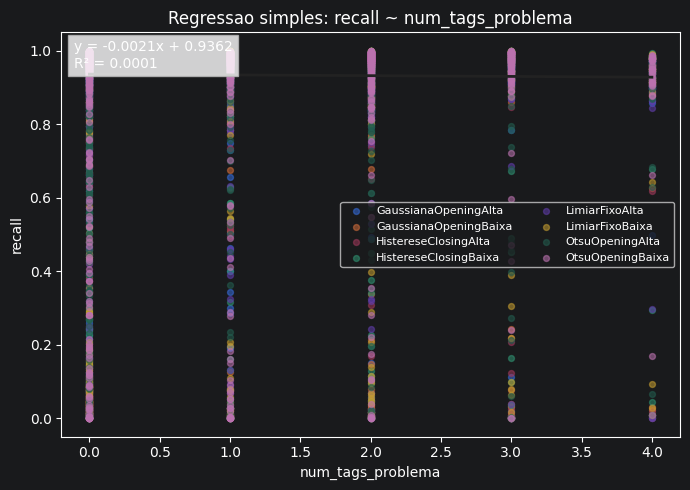

In [7]:
texto_regressao = 'A regressao simples usa num_tags_problema como proxy de dificuldade.'

for metric_name in metric_names:
    df_plot = df_base_por_estrategia[['modelo', 'num_tags_problema', metric_name, 'nome_arquivo', 'execucao']].copy()
    fig, _ = plot_simple_regression(df_base_por_estrategia, 'num_tags_problema', metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'regressao', metric_name, 'vs', 'num_tags_problema'),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Interacao entre estrategia e dificuldade

Este bloco resume como cada tag de problema desloca as metricas de cada estrategia.


,estrategia_binarizacao,tag_name,metric_name,count_com_tag,count_sem_tag,mean_com_tag,mean_sem_tag,median_com_tag,median_sem_tag,delta_mean,delta_median,relative_delta_mean,adjusted_delta_mean,adjusted_delta_median,impact_direction,higher_is_better
12,HistereseClosingAlta,tag_angulo_extremo,iou,644,4774,0.902625,0.907145,0.968326,0.968973,-0.004520,-0.000647,-0.004982,-0.004520,-0.000647,piora,True
24,LimiarFixoAlta,tag_angulo_extremo,iou,644,4774,0.894694,0.899030,0.964090,0.963838,-0.004337,0.000252,-0.004824,-0.004337,0.000252,piora,True
6,GaussianaOpeningBaixa,tag_angulo_extremo,iou,644,4774,0.903355,0.907340,0.968306,0.969063,-0.003984,-0.000757,-0.004391,-0.003984,-0.000757,piora,True
0,GaussianaOpeningAlta,tag_angulo_extremo,iou,644,4774,0.899128,0.902034,0.966233,0.964771,-0.002906,0.001463,-0.003221,-0.002906,0.001463,piora,True
30,LimiarFixoBaixa,tag_angulo_extremo,iou,644,4774,0.904698,0.907520,0.968650,0.969003,-0.002822,-0.000352,-0.003109,-0.002822,-0.000352,piora,True
18,HistereseClosingBaixa,tag_angulo_extremo,iou,644,4774,0.907771,0.907473,0.967646,0.968054,0.000299,-0.000408,0.000329,0.000299,-0.000408,melhora,True
36,OtsuOpeningAlta,tag_angulo_extremo,iou,644,4774,0.920572,0.913610,0.967875,0.967649,0.006962,0.000226,0.007621,0.006962,0.000226,melhora,True
42,OtsuOpeningBaixa,tag_angulo_extremo,iou,644,4774,0.926616,0.916990,0.968290,0.968836,0.009626,-0.000545,0.010497,0.009626,-0.000545,melhora,True
7,GaussianaOpeningBaixa,tag_baixo_contraste,iou,1442,3976,0.885747,0.914525,0.958042,0.971018,-0.028778,-0.012977,-0.031468,-0.028778,-0.012977,piora,True
31,LimiarFixoBaixa,tag_baixo_contraste,iou,1442,3976,0.886222,0.914787,0.958220,0.971001,-0.028565,-0.012781,-0.031226,-0.028565,-0.012781,piora,True


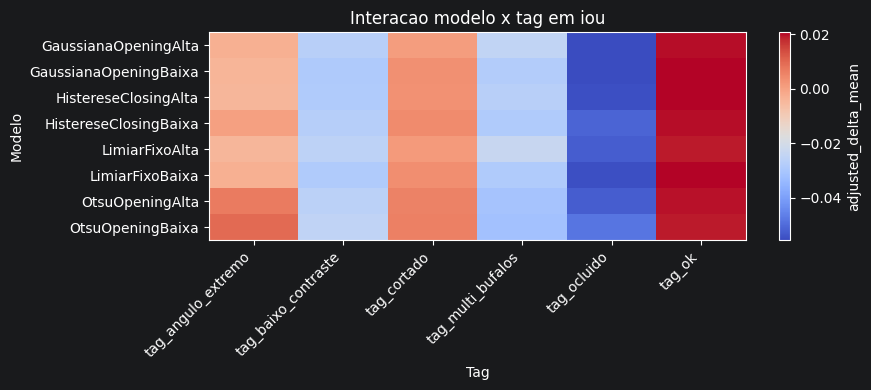

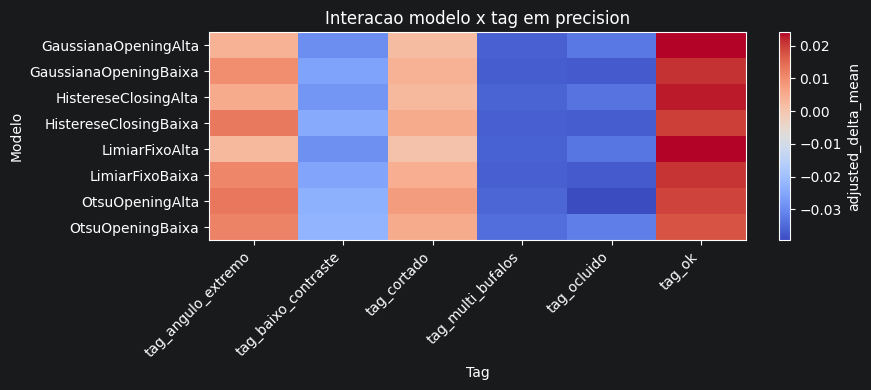

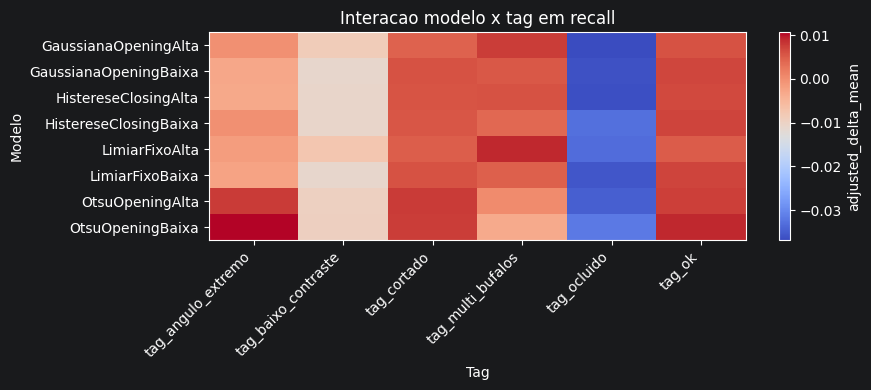

In [8]:
texto_interacoes = 'Este bloco resume como cada tag de problema desloca as metricas de cada estrategia.'
df_tabela_interacoes = df_interacoes_tag_estrategia.sort_values(['metric_name', 'tag_name', 'adjusted_delta_mean']).head(30).copy()
display(df_tabela_interacoes)
export_table_csv(artifact_output_dir, build_artifact_stem('notebook_07_segmentacao_binarizada', 'tabela', 'interacao_estrategia_tag_top30'), df_tabela_interacoes)

df_interacoes_plot = df_interacoes_tag_estrategia.rename(columns={'estrategia_binarizacao': 'nome_modelo'})
for metric_name in interaction_metrics:
    df_plot = df_interacoes_tag_estrategia.loc[df_interacoes_tag_estrategia['metric_name'] == metric_name].copy()
    fig, _ = plot_model_tag_interaction_heatmap(df_interacoes_plot, metric_name)
    export_figure_with_csv(
        artifact_output_dir,
        build_artifact_stem('notebook_07_segmentacao_binarizada', 'interacao_estrategia_tag', metric_name),
        fig,
        df_plot,
    )
    plt.show()
    plt.close(fig)


## Artefatos exportados

Os graficos e tabelas deste notebook sao exportados em PNG e CSV para consumo posterior por IA, sem gerar PDF.


In [9]:
print(f'Artefatos do notebook 07 salvos em: {artifact_output_dir}')


Artefatos do notebook 07 salvos em: /home/victor/Desktop/projeto-bufalos/worktrees/analise-estatistica-segmentacao-bruta/generated/notebook_07_segmentacao_binarizada
